## **Customer Support Ticket Classification,NLP and Multi-Model Pipeline**

> **Description:** Imports preprocessing utilities, vectorizes ticket text, 
             and trains models


In [ ]:
import sys

from pathlib import Path
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = str(BASE_DIR / "src")

if src_path not in sys.path:
    sys.path.append(src_path)

from utils import LoadData, Eda, TextPreprocessor, FeatureEngineer, TrainModel, SavingModel

print("Done!")

Done!


**Load Data**

In [ ]:
csv_path = str(BASE_DIR / "data" / "customer_support_tickets.csv")

In [15]:
loader = LoadData(csv_path)
df = loader.load_data()

[INFO] Dataset loaded successfully Shape: (8469, 17)


In [16]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


**EDA**

In [17]:
eda = Eda(df)
eda.analyze()


--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str  

**Visuakization**

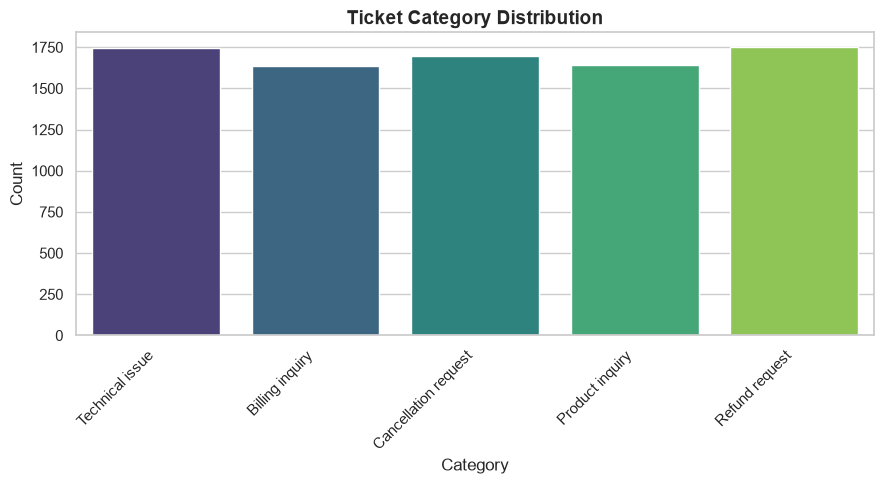

In [18]:
eda.plot_distribution("Ticket Type")

**Text Preprocessing**

In [19]:
preprocessing = TextPreprocessor()

desc_col = "Ticket Description"  
target_col = "Ticket Type"       

df["cleaned_text"] = df[desc_col].apply(preprocessing.clean_text)
df[["cleaned_text", target_col]].head()

,cleaned_text,Ticket Type
0,issue product purchased please assist billing ...,Technical issue
1,issue product purchased please assist need cha...,Technical issue
2,facing problem product purchased product purch...,Technical issue
3,issue product purchased please assist problem ...,Billing inquiry
4,issue product purchased please assist note sel...,Billing inquiry


**Feature Engineering**

In [20]:
Fe = FeatureEngineer(max_features=5000)

**Train-Test Split**

In [21]:
X_train, X_test, y_train, y_test = Fe.prepare_data(df["cleaned_text"], df["Ticket Type"])

[INFO] Vectorizing text corpus using TF-IDF...


**Model Training**

In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(df["Ticket Type"])
X_train, X_test, y_train, y_test = Fe.prepare_data(df["cleaned_text"], y_encoded)

training = TrainModel()

[INFO] Vectorizing text corpus using TF-IDF...


**Model Evaluation**


--- TRAINING & COMPARING MODELS ---
[RESULT] Logistic Regression Accuracy: 0.1907
[RESULT] Naive Bayes Accuracy: 0.1901
[RESULT] Support Vector Machine Accuracy: 0.1919
[RESULT] Random Forest Accuracy: 0.1913
[RESULT] XGBoost Accuracy: 0.2054

BEST MODEL: XGBoost (0.2054)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.19      0.15      0.17       357
           1       0.21      0.23      0.22       327
           2       0.21      0.21      0.21       316
           3       0.20      0.23      0.21       345
           4       0.22      0.21      0.21       349

    accuracy                           0.21      1694
   macro avg       0.21      0.21      0.20      1694
weighted avg       0.20      0.21      0.20      1694


--- CONFUSION MATRIX ---
[[54 69 65 86 83]
 [46 75 71 82 53]
 [62 49 66 72 67]
 [66 83 54 79 63]
 [55 81 61 78 74]]


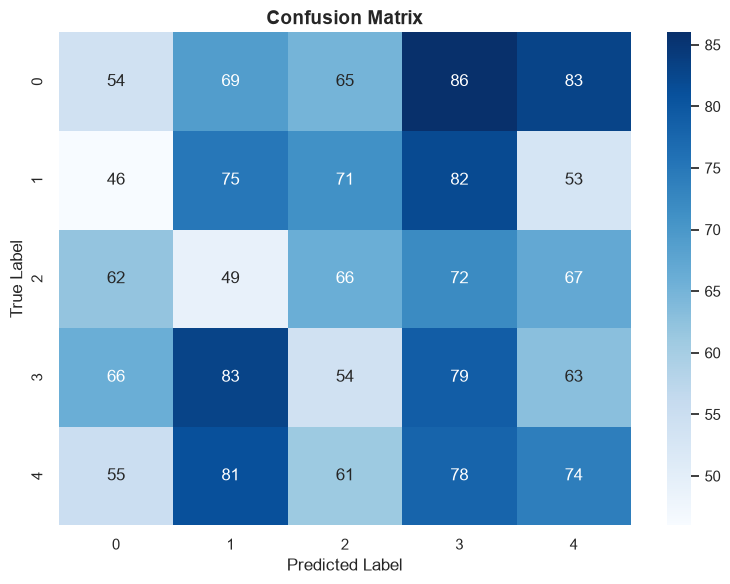

In [23]:
best_model = training.train_and_evaluate(X_train, X_test, y_train, y_test)

**Saving Model**

In [24]:
SavingModel.save_model(
    model = best_model, 
    vectorizer = Fe.vectorizer, 
    model_name = training.best_model_name, 
    filename="best_ticket_classifier.pkl"
)

[INFO] Successfully saved model package as 'best_ticket_classifier.pkl'
